# <u>Logistic Regression</u>

### Prerequisites:
* <a href="../../Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basics</a>

## Topics

* [0. Target encoding](#code)
* [1. Core idea](#idea)
* [2. Hypothesis Space](#hypothesis)
* [3. Interpretation via Logit](#logit)
* [4. Loss Function (Log-Loss / Cross-Entropy)](#loss)
* [5. Numerical Optimization](#optim)
* [6. Descision Boundary](#boundary)
* [7. Important practical notes](#notes)
* [8. Logistic Regression Implementation (Gradient Descent)](#gd)
* [9. Logistic Regression library](#library)
    

In [146]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
import pandas as pd # for dataframes and one hot encoding
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from sklearn.preprocessing import OneHotEncoder # for one hot encoding
from sklearn.datasets import make_classification # generate datasets for classification
from sklearn.linear_model import LogisticRegression # do Logistic Regression
from sklearn.linear_model import LogisticRegressionCV # do Logistic Regression with cross validation
from sklearn.model_selection import GridSearchCV # do Logistic Regression (or other ML algorithms) with cross validation
print("Setup complete")

Setup complete


<a class="anchor" id="code"></a>
# 0. Target encoding

- Classification goal: Predict a discrete class label out of $g$ classes $\{C_1,\ldots,C_g\}=\mathcal{Y} \ni y$ with $2 \leq g \leq \infty$
- Binary classification ($g = 2$)
    - Labels are usually encoded as: $\mathcal{Y}=\{0,1\}$ or $\mathcal{Y}=\{-1,+1\}$ 

- Multiclass classification ($g \geq 3$)
    - Instead of using label encoding like $\mathcal{Y}=\{1,\ldots,g\}$, we often use one-hot encoding $o(y)$:
        - Each class is represented as a vector of length $g$
        - Only one position is 1, others are 0
        - In notation $o_k(y)=\mathbb{I}(y=k) \in \{0,1\}$
        - Example:
            - Setosa $\rightarrow$ (1, 0, 0)
            - Versicolor $\rightarrow$ (0, 1, 0)
            - Virginica $\rightarrow$ (0, 0, 1)

```python
# OneHotEncoder (sklearn)

from sklearn.preprocessing import OneHotEncoder
import numpy as np

X = np.array([["Setosa"], ["Setosa"], ["Versicolor"], ["Virginica"], ["Setosa"]])
# shape (n_samples, 1) for a single categorical feature

encoder = OneHotEncoder(
    categories="auto", # determine categories automatically from data
    drop=None, # can drop one category to avoid multicollinearity (e.g. 'first')
    sparse_output=False, # return dense array (True returns sparse matrix)
    dtype=float,# desired output dtype
    handle_unknown="error" # or 'ignore' to handle unseen categories during transform
)

encoder.fit(X) # learns unique categories per feature

encoder.categories_ # list of arrays, each containing categories for a feature
encoder.n_features_in_ # number of input features seen during fit()

X_encoded = encoder.transform(X) # apply one-hot encoding
# each category becomes a binary column

X_encoded = encoder.fit_transform(X) # shortcut

# inverse transform (back to original labels)
X_original = encoder.inverse_transform(X_encoded)




# pd.get_dummies (pandas)

import pandas as pd

df = pd.DataFrame({
    "Species": ["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]
})

# basic one-hot encoding
dummies = pd.get_dummies(df["Species"])
# creates one column per category with 0/1 values

# options
dummies = pd.get_dummies(
    df["Species"],
    prefix="Species", # prefix for column names
    drop_first=False, # drop first category (useful for regression)
    dtype=int # set dtype (e.g. int instead of bool)
)

# multiple columns
df_multi = pd.DataFrame({
    "Species": ["Setosa", "Versicolor", "Virginica"],
    "Color": ["Red", "Blue", "Red"]
})

dummies_multi = pd.get_dummies(df_multi)
# automatically encodes all categorical columns

# join back to original dataframe
df_encoded = pd.get_dummies(df, columns=["Species"])

# notes:
# - returns a DataFrame (not numpy array)
# - automatically detects categorical columns (object/category dtype)
# - no explicit fit() step (unlike sklearn)

```

In [147]:
labels = ["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]

# get unique classes
classes = list(set(labels))

# Label encoding: map each class to an integer
class_to_index = {c: i for i, c in enumerate(classes)}

encoded = [class_to_index[label] for label in labels]

print("Classes:", classes)
print("Original Labels:", labels)
print("Encoded:", encoded)

Classes: ['Setosa', 'Virginica', 'Versicolor']
Original Labels: ['Setosa', 'Setosa', 'Versicolor', 'Virginica', 'Setosa']
Encoded: [0, 0, 2, 1, 0]


In [148]:
labels = ["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]

classes = sorted(list(set(labels))) # get unique values and then sort after letter (ASCII codes)
class_to_index = {c: i for i, c in enumerate(classes)}

g = len(classes)

# One-hot encoding
one_hot = []
for label in labels:
    vector = [0] * g # g zeros
    vector[class_to_index[label]] = 1 
    one_hot.append(vector)

print("Classes:", classes)
print("One-hot encoded:")
for v in one_hot:
    print(v)

Classes: ['Setosa', 'Versicolor', 'Virginica']
One-hot encoded:
[1, 0, 0]
[1, 0, 0]
[0, 1, 0]
[0, 0, 1]
[1, 0, 0]


In [149]:
labels = ["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]

classes = np.unique(labels)
class_to_index = {c: i for i, c in enumerate(classes)}

indices = np.array([class_to_index[l] for l in labels])

# One-hot encoding
one_hot = np.eye(len(classes))[indices]

print("Classes:", classes)
print("One-hot:\n", one_hot)

Classes: ['Setosa' 'Versicolor' 'Virginica']
One-hot:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [150]:
labels = np.array(["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
one_hot = encoder.fit_transform(labels)

print("Categories:", encoder.categories_)
print("One-hot:\n", one_hot)

Categories: [array(['Setosa', 'Versicolor', 'Virginica'], dtype='<U10')]
One-hot:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [151]:
labels = ["Setosa", "Setosa", "Versicolor", "Virginica", "Setosa"]

df = pd.DataFrame({"Species": labels})

one_hot = pd.get_dummies(df["Species"],dtype="int")

print(one_hot)

   Setosa  Versicolor  Virginica
0       1           0          0
1       1           0          0
2       0           1          0
3       0           0          1
4       1           0          0


<a class="anchor" id="idea"></a>
# 1. Core idea

- Logistic regression is a discriminant model for binary classification
- It directly models the probability of one class (usually class 1)
- Start with a linear model: $$f(x) = \theta^\top x$$
- &#10071; Problem: Linear outputs are not valid probabilities (can be < 0 or >1)
- &#128073; Solution: apply the logistic (sigmoid) function to "squash" values into $[0,1]$
$$
\pi(x \mid \theta) = \frac{\exp(\theta^\top x)}{1+\exp(\theta^\top x)}=\frac{1}{1+\exp(-\theta^\top x)}=s(\theta^\top x)=s(f(x))
$$
- This gives a valid probability model


<a class="anchor" id="hypothesis"></a>
# 2. Hypothesis space

- Logistic regression models: $$\mathcal{H}=\left\{\pi: \mathcal{X} \rightarrow [0,1] \mid \pi(x \mid \theta)=s(\theta^\top x) \mid \theta \in \mathbb{R}^{p \times 1}\right\}$$
- Linear combination $\rightarrow$ transformed $\rightarrow$ probability
- The model is linear in the parameters, but nonlinear in output

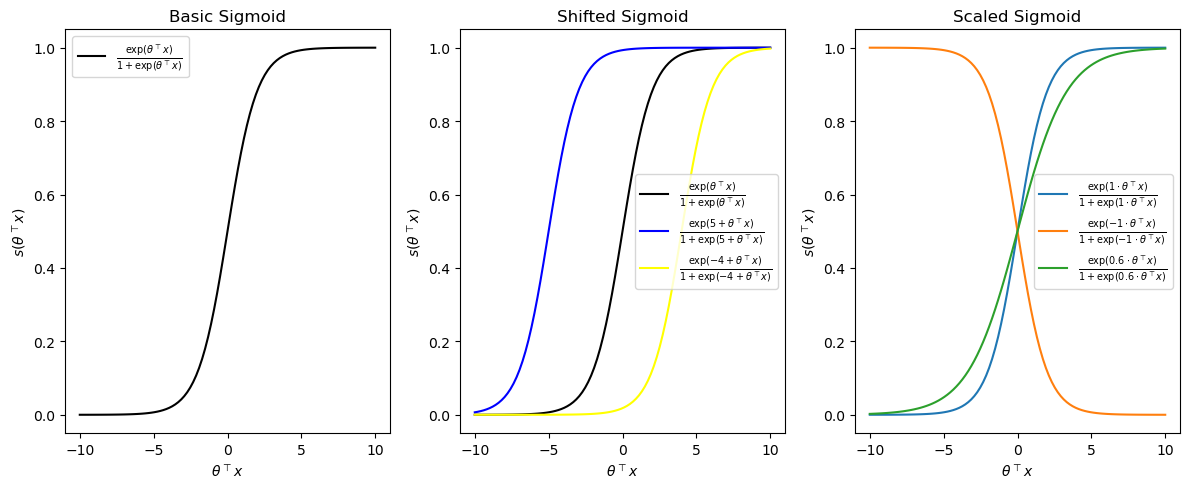

In [152]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

n = 100
scores = np.linspace(-10, 10, n)
sig = sigmoid(scores)

plt.figure(figsize=(12, 5))

# Plot 1: Basic sigmoid 
plt.subplot(1, 3, 1)
plt.plot(scores, sig, color="black",
         label=r"$\frac{\exp(\theta^\top x)}{1+\exp(\theta^\top x)}$")
plt.title("Basic Sigmoid")
plt.xlabel(r"$\theta^\top x$")
plt.ylabel(r"$s(\theta^\top x)$")
plt.legend()

# Plot 2: Shifted sigmoid 
a, b = 5, -4
plt.subplot(1, 3, 2)
plt.plot(scores, sig, color="black",label=r"$\frac{\exp(\theta^\top x)}{1+\exp(\theta^\top x)}$")
plt.plot(scores, sigmoid(scores + a), color="blue",label=rf"$\frac{{\exp({a}+\theta^\top x)}}{{1+\exp({a}+\theta^\top x)}}$")
plt.plot(scores, sigmoid(scores + b), color="yellow",label=rf"$\frac{{\exp({b}+\theta^\top x)}}{{1+\exp({b}+\theta^\top x)}}$")
plt.title("Shifted Sigmoid")
plt.xlabel(r"$\theta^\top x$")
plt.ylabel(r"$s(\theta^\top x)$")
plt.legend()

# Plot 3: Scaled sigmoid 
plt.subplot(1, 3, 3)
scalers = [1, -1, 0.6]

for k in scalers:
    plt.plot(scores, sigmoid(k * scores),label=rf"$\frac{{\exp({k} \cdot \theta^\top x)}}{{1+\exp({k} \cdot \theta^\top x)}}$")

plt.title("Scaled Sigmoid")
plt.xlabel(r"$\theta^\top x$")
plt.ylabel(r"$s(\theta^\top x)$")
plt.legend()

plt.tight_layout()
plt.show()

<a class="anchor" id="logit"></a>
# 3. Interpretation via Logit

- The inverse of the sigmoid is the logit (log-odds): 
$$
\begin{align*}
s(\theta^\top x)&=\frac{1}{1+\exp(-\theta^\top x)} \mid ()^{-1} \\ \Leftrightarrow
\frac{1}{s(\theta^\top x)}&=1+\exp(-\theta^\top x) \mid -1 \\ \Leftrightarrow
\frac{1}{s(\theta^\top x)}-1&=\exp(-\theta^\top x) \\ \Leftrightarrow
\frac{1-s(\theta^\top x)}{s(\theta^\top x)}&=\exp(-\theta^\top x) \mid \log() \\ \Leftrightarrow
\ln\left(\frac{1-s(\theta^\top x)}{s(\theta^\top x)}\right)&=-\theta^\top x \mid \cdot (-1)\\ \Leftrightarrow
-\ln\left(\frac{1-s(\theta^\top x)}{s(\theta^\top x)}\right)&=\theta^\top x \\ \Leftrightarrow
\ln\left(\left(\frac{1-s(\theta^\top x)}{s(\theta^\top x)}\right)^{-1}\right)&=\theta^\top x \\ \Leftrightarrow
\ln\left(\frac{s(\theta^\top x)}{1-s(\theta^\top x)}\right)&=\theta^\top x  \Leftrightarrow \underbrace{s^{-1}(\overbrace{\pi(x \mid \theta)}^{\in [0,1]})}_{\in (-\infty,\infty)}= \ln\left(\frac{\pi(x \mid \theta)}{1-\pi(x \mid \theta)}\right) 
\end{align*}
$$

- $s^{-1}(\pi(x \mid \theta))$ is called **log odds** because $\frac{\pi(x \mid \theta)}{1-\pi(x \mid \theta)}$ represents the odds of success vs failure
- For example, if $\pi(x \mid \theta)=3/4$, then odds $=\frac{3/4}{1-3/4}=\frac{3/4}{1/4}=\frac{3}{1} \Rightarrow$ odds of success are 3 to 1

- Properties:
    - As $\pi(x \mid \theta) \rightarrow 1$, $s^{-1}(\pi(x \mid \theta)) \rightarrow +\infty$
    - As $\pi(x \mid \theta) \rightarrow 0$, $s^{-1}(\pi(x \mid \theta)) \rightarrow -\infty$
    - At $\pi(x \mid \theta) = 0.5$, $s^{-1}(\pi(x \mid \theta)) = 0$

&#128073; So:
- $f(x)=\theta^\top x > 0 \rightarrow s(f(x))=\pi(x \mid \theta) > 0.5$
- $f(x)=\theta^\top x < 0 \rightarrow s(f(x))=\pi(x \mid \theta) < 0.5$

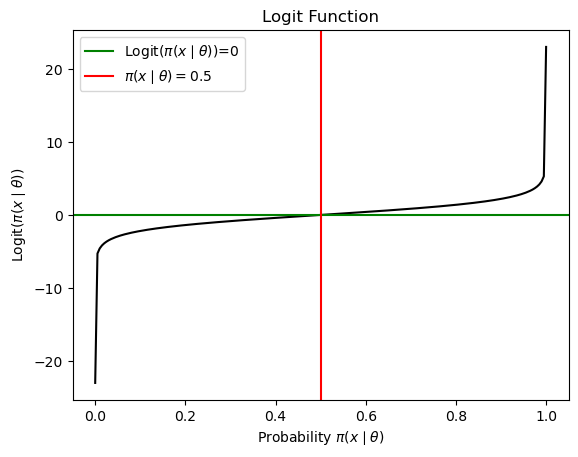

In [153]:
def logit(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)  # avoid 0 and 1
    return np.log(p / (1 - p))

probs = np.linspace(0,1,200)
log_odds = logit(probs)

plt.plot(probs, log_odds, color="black")
plt.axhline(0,color="green",label=rf"Logit($\pi(x \mid \theta)$)=0")
plt.axvline(0.5,color="red",label=rf"$\pi(x \mid \theta)=0.5$")
plt.xlabel(rf"Probability $\pi(x \mid \theta)$")
plt.ylabel(rf"Logit($\pi(x \mid \theta)$)")
plt.title("Logit Function")
plt.legend()
plt.show()

<a class="anchor" id="logit"></a>
# 5. Loss Function (Log-Loss / Cross-Entropy)

**Derived from maximum likelihood estimation**

Our model is: $$\pi(x \mid \theta)=p(y=1 \mid x, \theta) \\ 1-\pi(x \mid \theta)=p(y=0 \mid x,\theta)$$

- Likelihood for a single data point
    - derive a single expression that works for case $y=1$ and case $y=0$
    - &#128073; Combine both using exponents: $$p(y \mid x,\theta)=\pi(x \mid \theta)^{y}(1-\pi(x \mid \theta))^{1-y}$$
    - If $y=1$ then $p(y=1 \mid x,\theta)=\pi(x \mid \theta)$ and if $y=0$ then $p(y=0 \mid x,\theta)=1-\pi(x \mid \theta)$

- Likelihood for the full dataset
    - Assuming independent observations, the likelihood is: $$\mathcal{L}(\theta)=\prod_{i=1}^n \pi(x^{(i)} \mid \theta)^{y^{(i)}}(1-\pi(x^{(i)} \mid \theta))^{1-y^{(i)}}$$

- Take the log (log-likelihood)
    - Products are hard to optimize so take logarithm 
    
$$
\begin{align*}
\log(\mathcal{L}(\theta))
&=\log\left(\prod_{i=1}^n  \pi(x^{(i)} \mid \theta)^{y^{(i)}}(1-\pi(x^{(i)} \mid \theta))^{1-y^{(i)}}\right)\\
&=\sum_{i=1}^n \log\left( \pi(x^{(i)} \mid \theta)^{y^{(i)}}(1-\pi(x^{(i)} \mid \theta))^{1-y^{(i)}}\right)\\
&=\sum_{i=1}^n \log(\pi(x^{(i)} \mid \theta)^{y^{(i)}}) + \log((1-\pi(x^{(i)} \mid \theta))^{1-y^{(i)}})\\
&=\sum_{i=1}^n y^{(i)}\log(\pi(x^{(i)} \mid \theta)) + (1-y^{(i)})\log((1-\pi(x^{(i)} \mid \theta)))\\
\end{align*}
$$

- Turn maximization into minimization
    - MLE does $\arg\max_\theta \log(\mathcal{L}(\theta))$ but we need $\arg\min_\theta$
    - $\arg\max_\theta \log(\mathcal{L}(\theta))=\arg\min_\theta -\log(\mathcal{L}(\theta))$
$$-\log(\mathcal{L}(\theta))=\sum_{i=1}^n -y^{(i)}\log(\pi(x^{(i)} \mid \theta)) - (1-y^{(i)})\log((1-\pi(x^{(i)} \mid \theta)))$$

- Resulting empirical loss (called Bernoulli,binomial,log or cross-entropy loss) $$L(y,\pi(x \mid \theta))=-y\log(\pi(x \mid \theta)) - (1-y)\log((1-\pi(x \mid \theta)))$$

- Key properties:
    - No closed form solution use numerical optimization methods like Gradient Descent
    - Penalizes confident wrong predictions heavily
    - Standard for classification (also used in neural networks)

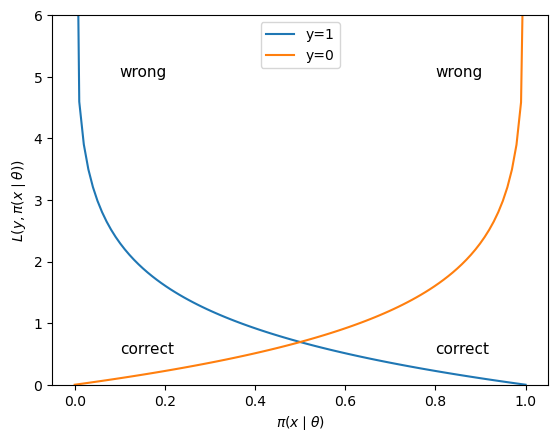

In [154]:
n = 100
probs=np.linspace(0.00001,0.9999,n) # avoid 0 and 1 since np.log(0)=np.log(1-1)=-inf
log_losses_pos = -1*np.log(probs)-(1-1)*np.log(1-probs) # log losses for y = 1
log_losses_neg = -0*np.log(probs)-(1-0)*np.log(1-probs) # log losses for y = 0

plt.plot(probs,log_losses_pos,label="y=1")
plt.plot(probs,log_losses_neg,label="y=0")
plt.xlabel(r"$\pi(x \mid \theta)$")
plt.ylabel(r"$L(y,\pi(x \mid \theta))$")
plt.ylim((0,6))
plt.legend()

plt.text(0.1, 5, "wrong", fontsize=11)
plt.text(0.8, 5, "wrong", fontsize=11)
plt.text(0.1, 0.5, "correct", fontsize=11)
plt.text(0.8, 0.5, "correct", fontsize=11)
plt.show()

<a class="anchor" id="optim"></a>
# 6. Numerical Optimization

- Objective: Minimize empirical risk (sum of losses)
- Log-loss is convex loss $\rightarrow$ unique solution (under conditions) but no analytical solution
- Unbounded optimization for linear separable data

## &#128200; What is linear separable

The data is linearly separable if there exists some vector $\theta$ such that:
- $\theta^\top x > 0$ for all $y=1$
- $\theta^\top x < 0$ for all $y=0$


## &#128680; Why the optimization becomes unbounded

Here is the key idea:
- Logistic regression does not just want correct classification
- It wants high confidence (probabilities close to 0 or 1)

Now suppose we already found a separating $\theta$ then we can scale it with $c$ to get $c\theta := \tilde{\theta}$.

Then:
- For $y=1$: $\tilde{\theta}^\top x \overset{c \rightarrow +\infty}{\longrightarrow} +\infty \Rightarrow \pi(x \mid \theta) \rightarrow 1 \Rightarrow \log(\pi(x \mid \theta)) \rightarrow 0$ 
- For $y=0$: $\tilde{\theta}^\top x \overset{c \rightarrow +\infty}{\longrightarrow} -\infty \Rightarrow \pi(x \mid \theta) \rightarrow 0 \Rightarrow \log(1-\pi(x \mid \theta)) \rightarrow 0$ 

&#128073; So the loss $L(y,\pi(x \mid \theta)) \rightarrow 0$

### &#10071; Problem
- The loss keeps getting smaller and smaller
- But no finite $\theta$ achieves the minimum
- The "best" solution is: $\lVert \tilde{\theta} \rVert \rightarrow \infty$

### &#129504; Regularization as solution
$$
L(y,\pi(x \mid \theta)) + \underbrace{\lambda \lVert \theta \rVert_2^2}_{\text{penalty}}
$$

Now there is a trade-off:
- Fit data well 
- Keep weights small 

&#128073; This forces a finite optimal solution

<p align="center">
<img src="linear_separable.png" width="350"/>
</p>

<a class="anchor" id="boundary"></a>
# 6. Descision Boundary

**A Descision boundary in Logistic Regression is the set of data points $x \in \mathcal{X}$ for which $\theta^\top x = 0$ or $\pi(x \mid \theta)=0.5$.**

- Logistic regression is a linear classifier
- Decision boundary: $$\theta^\top x = 0$$
- Produces a linear separation (hyperplane)

Example for $(x_1,x_2)^\top \in \mathcal{X}=\mathbb{R}^2$ and $\theta \in \mathbb{R}^p$ with $p=2$ (no bias term)
$$
\theta^\top x = 0 \Leftrightarrow \theta_1 x_1 + \theta_2 x_2 = 0 \Leftrightarrow  x_2 = - \frac{\theta_1}{\theta_2} x_1 \Rightarrow \text{Line (through origin)}
$$

Example for $(x_1,x_2)^\top \in \mathcal{X}=\mathbb{R}^2$ and $\theta \in \mathbb{R}^{p+1}$ with $p=2$ (with bias term)
$$
\theta^\top x = 0 \Leftrightarrow \theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0 \Leftrightarrow  x_2 = - \frac{\theta_1}{\theta_2} x_1 - \frac{\theta_0}{\theta_2} \Rightarrow \text{Line (not necessarily through origin)}
$$

<a class="anchor" id="notes"></a>
# 7. Importent practical notes

- If data is perfectly separable:
    - Optimization becomes unbounded

    - $\rightarrow$ Need regularization

- Using least squares instead:
    - Leads to non-convex problem $\rightarrow$ not preferred

<a class="anchor" id="gd"></a>
# 8. Logistic Regression Implementation (Gradient Descent)

### 1. Initialize Parameters

* Initialize weights $\theta$ (including bias term) with zeros or small random values.
* Choose a learning rate $\alpha$.
* Set number of iterations $(\text{epochs})$.

---

### 2. Define the Sigmoid Function

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

* This maps linear outputs to probabilities in [0,1].

---

### 3. Compute Linear Combination

For each data point (matrix notation):
$$
z = X\theta \hspace{1 mm} \text{ or with bias } z = \theta_0 + X\theta
$$

---

### 4. Compute Predictions

Apply sigmoid:
$$
\hat{y} = \sigma(z)
$$

---

### 5. Compute the Loss (Log-Loss)

$$
L(y, \hat{y}) = -y \log(\hat{y}) - (1 - y)\log(1 - \hat{y})
$$

* Compute average loss over all training examples.

---

### 6. Compute Gradients

$$
L(y, \hat{y}) = -y \log(\hat{y}) - (1 - y)\log(1 - \hat{y})
$$
- $\hat{y}=\sigma(z) = \frac{1}{1 + e^{-z}}$
- $z=\theta^\top x$ or with bias $z=\theta_0 + \theta^\top x$

<p align="center">
<img src="tree.jpeg" width="350"/>
</p>

$$
\frac{\partial L}{\partial \theta} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \theta} \\
$$


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


$$
\begin{align*}
\frac{\partial L}{\partial \hat{y}} &= -y \frac{\partial}{\partial \hat{y}}\log(\hat{y}) - (1-y)\frac{\partial}{\partial \hat{y}}\log(1-\hat{y}) \\
& = -\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}} \frac{\partial}{\partial \hat{y}}(1-\hat{y}) \\
& = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}  \\
\end{align*}
$$


</div>

<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

$$
\begin{align*}
\frac{\partial \hat{y}}{\partial z}&= \frac{\partial}{\partial z}\frac{1}{1 + e^{-z}} \\
&= \frac{\partial}{\partial z}(1 + e^{-z})^{-1} \\
&= -1 \cdot (1 + e^{-z})^{-2} \frac{\partial}{\partial z} (1 + e^{-z})\\
&= -1 \cdot (1 + e^{-z})^{-2} (-e^{-z})\\
&= e^{-z} \cdot (1 + e^{-z})^{-2} \\
&= e^{-z} \cdot \frac{1}{(1 + e^{-z})^{2}} \\
&= e^{-z} \cdot \hat{y}^2 \\
\hat{y}=\frac{1}{1 + e^{-z}} &\Leftrightarrow 1 + e^{-z} = \frac{1}{\hat{y}} \\
&\Leftrightarrow e^{-z} = \frac{1}{\hat{y}} - 1 \\
&= (\frac{1}{\hat{y}} - 1) \cdot \hat{y}^2 \\
&= \hat{y} -  \hat{y}^2 \\
\end{align*}
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


$$
\begin{align*}
\frac{\partial z}{\partial \theta}&= \frac{\partial}{\partial \theta} \theta^\top x \\
&= x \\
\end{align*}
$$
Including bias:
$$
\begin{align*}
\frac{\partial z}{\partial \theta_0}&= \frac{\partial}{\partial \theta_0} \theta_0 + \theta^\top x \\
&= 1 \\
\end{align*}
$$


</div>
</div>

$$
\begin{align*}
\frac{\partial L}{\partial \theta} &= \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \theta} \\
&= (-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}})(\hat{y} -  \hat{y}^2)x \\
&= (-y(1-\hat{y})+(1-y)\hat{y})x \\
&= (\hat{y} -  y)x \hspace{1 mm} \text{ for one data point} \\
&= X^\top (\hat{y} -  y) \hspace{1 mm} \text{ for all data points}\\
&= \frac{1}{n} X^\top (\hat{y} -  y) \hspace{1 mm} \text{ scaling by } \frac{1}{n} \text{ does not change the minimizer, but improves numerical stability}\\
\end{align*}
$$
Again including bias we get
$$
\begin{align*}
\frac{\partial L}{\partial \theta}
&= \frac{1}{n}  (\hat{y} -  y) \hspace{1 mm} \text{ for one data point} \\
&= \frac{1}{n}  \sum_{i=1}^n (\hat{y} -  y) \hspace{1 mm} \text{ for all data point} \\
\end{align*}
$$



---

### 7. Update Parameters (Gradient Descent Step)

$$
\theta := \theta - \alpha \cdot \frac{\partial L}{\partial \theta}
$$

* Move parameters in direction that reduces loss.

---

### 8. Repeat Until Convergence

* Loop over steps 3–7 for all iterations
* Stop when:

  * Maximum iterations reached, or
  * Loss converges (changes very little)

---

### 9. Make Predictions

* Compute probability:
  $$
  \hat{y} = \sigma(X\theta)
  $$
* Convert to class labels using threshold:
  $$
  \hat{y}_{class} =
  \begin{cases}
  1 & \text{if } \hat{y} \geq 0.5 \\
  0 & \text{otherwise}
  \end{cases}
  $$

---

### 10. Evaluate Model

* Use metrics such as:

  * Accuracy
  * Precision / Recall
  * Confusion Matrix


bias term is -1.5005742561931468
coefficients are [0.07336989 0.30980058]


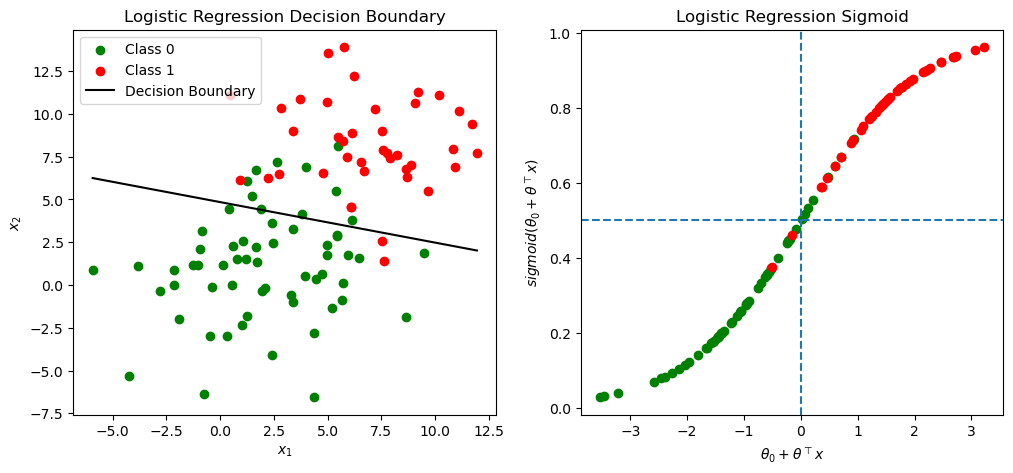

Class 0 and 1 Predictions:[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]
Accuracy: 0.88
Missclassification Error: 0.12


In [155]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_gd(X, y, lr=0.01, epochs=1000):
    n = len(y)
    
    # Initialize parameters
    bias = 0
    coeffs = np.zeros(X.shape[1])

    for _ in range(epochs):
        z = bias + X @ coeffs # compute scores
        
        pred = sigmoid(z) # apply sigmoid
        
        # Gradients
        error = pred - y
        grad_w = (1 / n) * X.T @ error
        grad_b = (1 / n) * np.sum(error)
        
        # Update parameters
        coeffs = coeffs - lr * grad_w
        bias = bias - lr * grad_b

    return bias, coeffs


np.random.seed(1900)
n = 100

# Split samples
n0 = int(0.6 * n)
n1 = n - n0

# Generate features from normal distributions
X0 = np.random.normal(loc=[2, 2], scale=3.0, size=(n0, 2))  # Class 0
X1 = np.random.normal(loc=[7, 7], scale=3.0, size=(n1, 2))  # Class 1

# Combine
X = np.vstack((X0, X1))
y = np.array([0]*n0 + [1]*n1)

# Train model 
bias, coeffs = logistic_gd(X, y)
print(f"bias term is {bias}")
print(f"coefficients are {coeffs}")

# Plot data (colored by class) 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0",color="green")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1",color="red")

# Decision boundary 
# b + theta1*x1 + theta2*x2 = 0  <-> x2 = -(theta1/theta2)x1 - b/theta2
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

if coeffs[1] != 0: # avoid diving by 0
    y_vals = -(coeffs[0]/coeffs[1]) * x_vals - bias/coeffs[1]
    plt.plot(x_vals, y_vals, label="Decision Boundary",color="black")
else:
    # vertical line case
    plt.axvline(x = -bias/coeffs[0], label="Decision Boundary")


plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Logistic Regression Decision Boundary")
plt.legend()

plt.subplot(1,2,2)
z = bias + X @ coeffs 
sig = sigmoid(z)
plt.axhline(0.5,linestyle="--")
plt.axvline(0,linestyle="--")
plt.scatter(z[y==0],sig[y==0],color="green")
plt.scatter(z[y==1],sig[y==1],color="red")
plt.xlabel(r"$\theta_0 + \theta^\top x$")
plt.ylabel(r"$sigmoid(\theta_0 + \theta^\top x)$")
plt.title("Logistic Regression Sigmoid")


plt.show()

# Evaluate model accuracy
def predict(X, bias, coeffs):
    probs = sigmoid(bias + X @ coeffs)
    return (probs >= 0.5).astype(int)

y_pred = predict(X,bias,coeffs)
print(f"Class 0 and 1 Predictions:{y_pred}")
accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)
mce = np.mean(y_pred != y) # short mce = 1 - accuracy
print("Missclassification Error:", mce)

<a class="anchor" id="library"></a>
# 9. Logistic Regression library

```python
# 1. Logistic Regression (scikit-learn)
from sklearn.linear_model import LogisticRegression

# Basic model
model1 = LogisticRegression(
    penalty="l2", # regularization type: "l1", "l2", "elasticnet", None
    C=1.0, # inverse regularization strength (smaller = stronger reg)
    solver="lbfgs", # optimization algorithm ("lbfgs", "liblinear", "saga", etc.)
    max_iter=1000, # number of iterations
    fit_intercept=True, # include bias term
    n_jobs=None # parallel jobs (-1 = use all cores)
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy
model1.coef_ # learned weights
model1.intercept_ # bias term


# 2. Logistic Regression with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"] # supports both l1 and l2
}

model2 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid, # regularization strength
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. Logistic Regression with built-in cross-validation
from sklearn.linear_model import LogisticRegressionCV

model3 = LogisticRegressionCV(
    Cs=10, # number of C values to try
    cv=5,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000
)

model3.fit(X, y)

model3.C_ # best C
model3.score(X, y)


# 4. Generate synthetic dataset
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500, # Total number of data points
    n_features=5, # Total number of features (columns)
    n_informative=3, # Number of features that actually contain useful signal
    n_redundant=0, # Number of features that are linear combinations of informative features
    n_classes=2, # Number of clusters (blobs) per class
    class_sep=0 # Controls how far apart the classes are
    random_state=42 # Same input -> same dataset every time
)


# 5. Train/Test Split + Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model5 = LogisticRegression(max_iter=1000)
model5.fit(X_train, y_train)

y_pred = model5.predict(X_test)

accuracy_score(y_test, y_pred) # accuracy
confusion_matrix(y_test, y_pred) # confusion matrix
classification_report(y_test, y_pred) # precision, recall, f1


# 6. Regularization variants
# L1 (sparse solution)
model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

# Elastic Net
model_en = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    max_iter=1000
)


# 7. Multiclass Logistic Regression
model_multi = LogisticRegression(
    multi_class="multinomial", # "ovr" or "multinomial"
    solver="lbfgs",
    max_iter=1000
)

model_multi.fit(X, y)


# 8. Feature scaling (important for Logistic Regression)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)


# 9. Decision function (raw scores)
model1.decision_function(X) # logits (before sigmoid)


# 10. Probability thresholding
probs = model1.predict_proba(X)[:, 1]
custom_preds = (probs >= 0.3).astype(int) # custom threshold
```

bias term is 0.038836726377062245
coefficients are [ 3.23549273 -3.05237102]


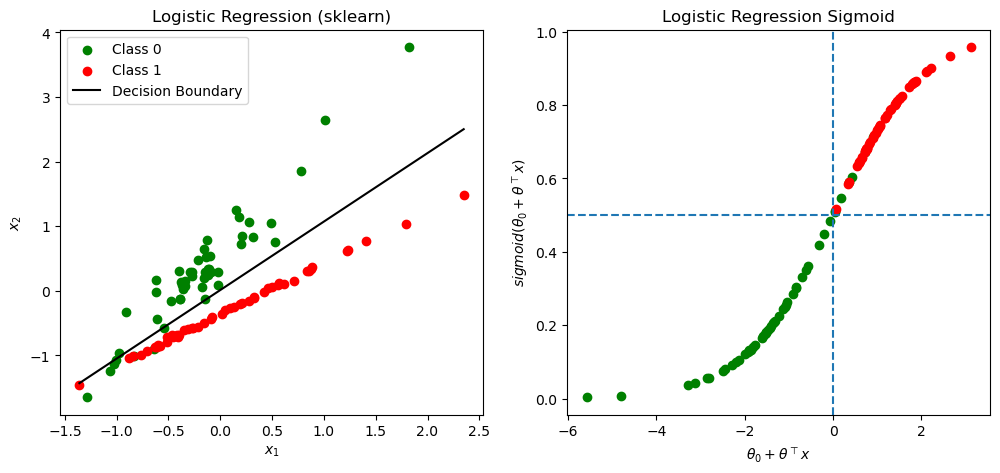

Class 0 and 1 Predictions: [1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 1 1 1 1 0 0 1 1 0 1
 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1
 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 0]
Accuracy: 0.93
Missclassification Error: 0.07


In [163]:
# 1. Generate synthetic dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.2,
    random_state=2010
)

# 2. Train Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

bias = model.intercept_[0]
coeffs = model.coef_[0]

print(f"bias term is {bias}")
print(f"coefficients are {coeffs}")

# 3. Plot data
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0", color="green")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1", color="red")

# Decision boundary
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

if coeffs[1] != 0:
    y_vals = -(coeffs[0]/coeffs[1]) * x_vals - bias/coeffs[1]
    plt.plot(x_vals, y_vals, label="Decision Boundary", color="black")
else:
    plt.axvline(x=-bias/coeffs[0], label="Decision Boundary")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Logistic Regression (sklearn)")
plt.legend()

# 4. Sigmoid plot
plt.subplot(1,2,2)
z = bias + X @ coeffs
sig = 1 / (1 + np.exp(-z))

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.scatter(z[y==0], sig[y==0], color="green")
plt.scatter(z[y==1], sig[y==1], color="red")

plt.xlabel(r"$\theta_0 + \theta^\top x$")
plt.ylabel(r"$sigmoid(\theta_0 + \theta^\top x)$")
plt.title("Logistic Regression Sigmoid")

plt.show()

# 5. Evaluate model
y_pred = model.predict(X)

print(f"Class 0 and 1 Predictions: {y_pred}")

accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)

mce = np.mean(y_pred != y)
print("Missclassification Error:", mce)